In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/california-housing-prices/housing.csv


In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/california-housing-prices/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [6]:
cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

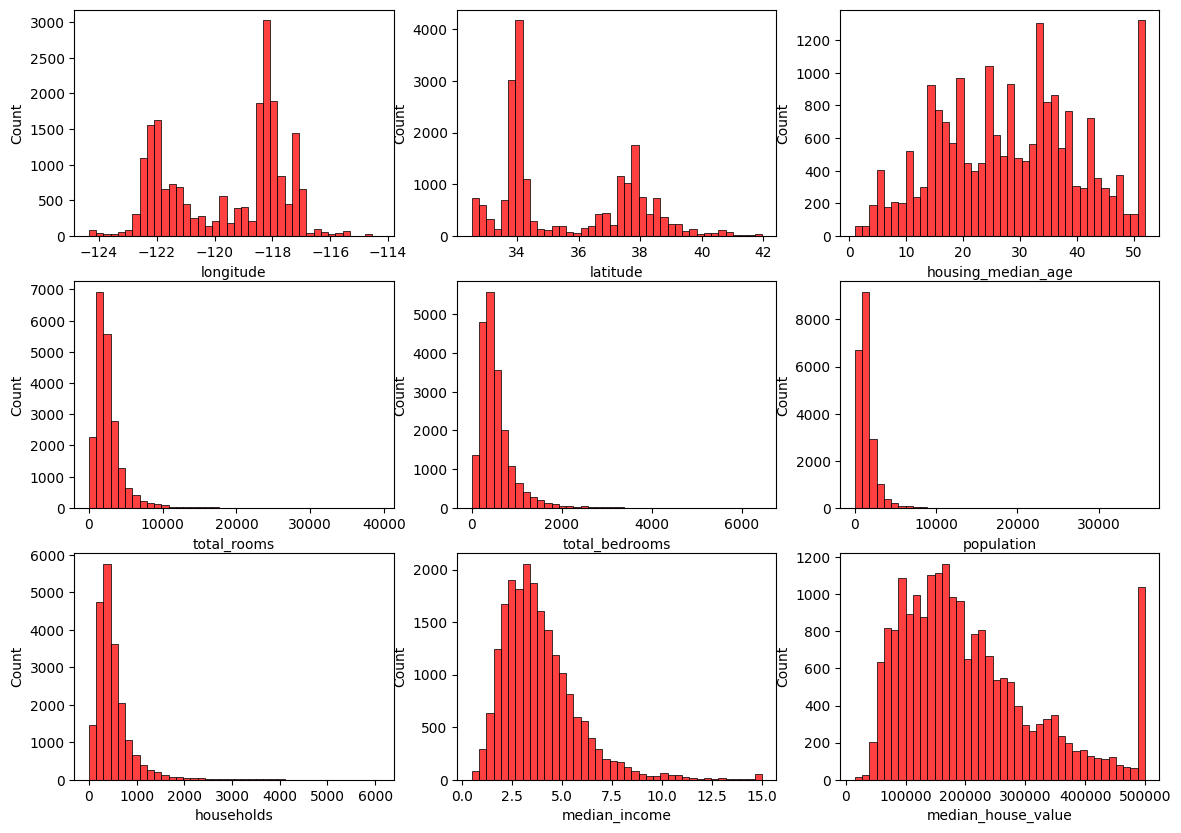

In [7]:
fig , axes = plt.subplots(nrows = 3 , ncols = 3 , figsize = (14 , 10))

for i , col in enumerate(cols) : 
    row = i // 3 
    col_idx = i % 3
    ax = axes[row , col_idx]
    sns.histplot(data = df , x = col , ax = ax , color = 'red' , bins = 40 )

plt.show()

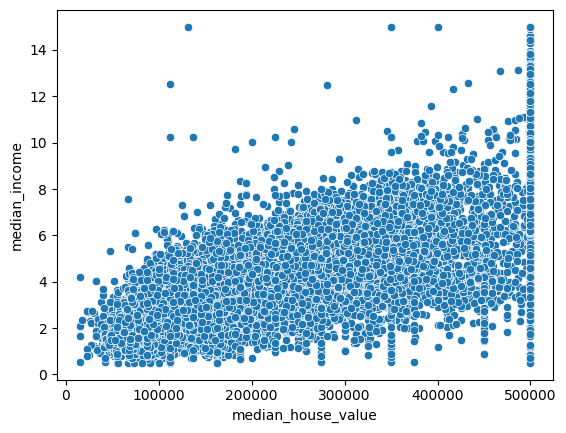

In [8]:
sns.scatterplot(data = df , x = 'median_house_value' , y = 'median_income')
plt.show()

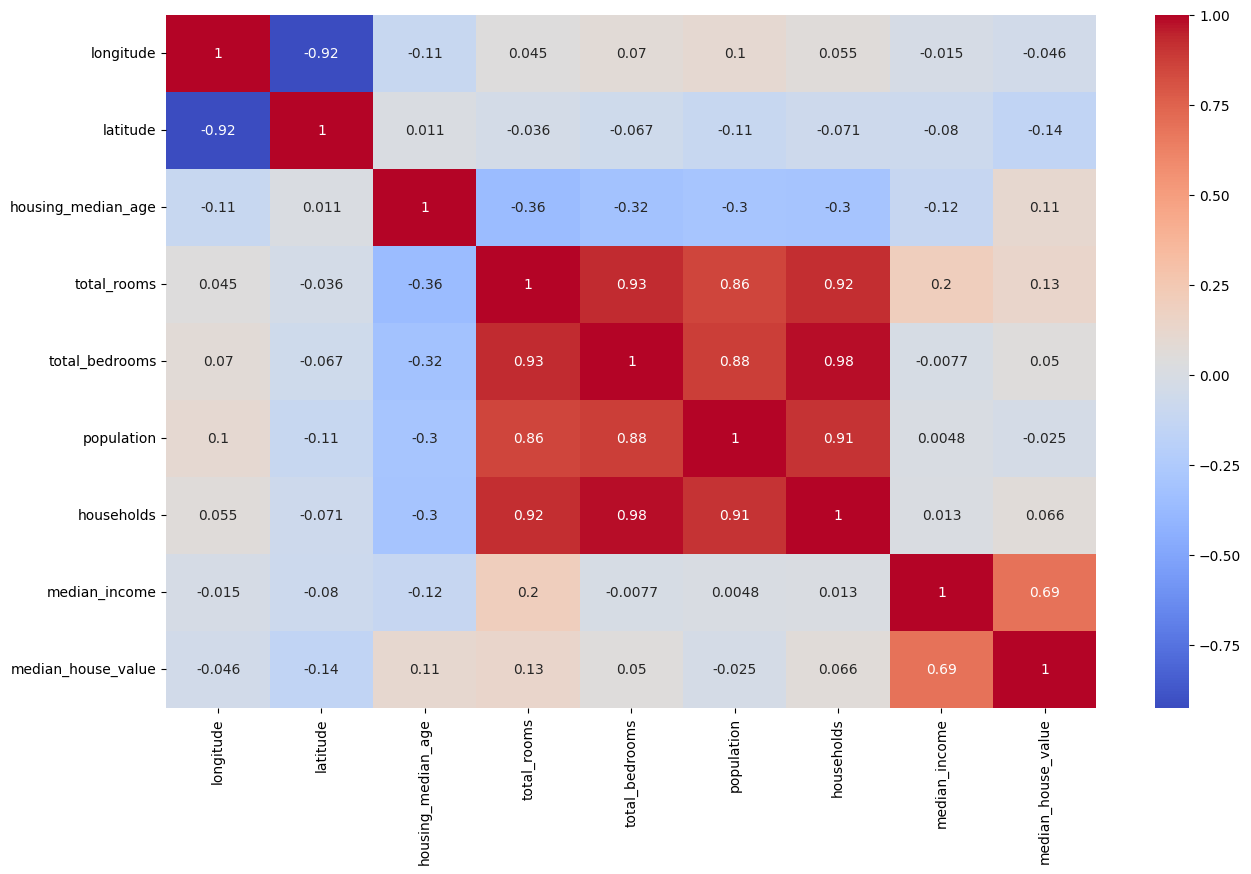

In [9]:
plt.figure(figsize = (15 , 9))
sns.heatmap(df.corr(numeric_only = True) , annot = True , cmap = 'coolwarm')
plt.show()

In [10]:
# Outlier Datas
def find_outlier_datas(df , treshold) : 
    outliers = {}
    outliers_info = {}
    numeric_cols = df.select_dtypes(include = ['float64' , 'int64'])

    for col in numeric_cols : 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - treshold * IQR
        upper_bound = Q3 + treshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
        'outliers_count' : outliers[col].shape[0], 
        'percentage ( % )' : 100 * outliers.shape[0] / df.shape[0],
        'lower_bound' :  lower_bound,
        'upper_bound' : upper_bound
        }  
    return pd.DataFrame(outliers_info)
      

In [11]:
find_outlier_datas(df , 1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outliers_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
percentage ( % ),0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [12]:
def remove_outliers_from_column (df , col , treshold = 1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1 

    lower_bound = Q1 - treshold * IQR
    upper_bound = Q3 + treshold * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [13]:
df = remove_outliers_from_column(df , 'median_house_value')
df.shape

(19569, 10)

In [14]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [16]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [17]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [18]:
df.drop(index = (df[df['ocean_proximity'] == 'ISLAND'].index) , axis = 0 , inplace = True)

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [20]:
transformer = ColumnTransformer(transformers = [
    ('onehot' , OneHotEncoder(drop = 'first' , dtype = int , handle_unknown = 'ignore') , ['ocean_proximity'])
] , remainder = 'passthrough')

In [21]:
df = (transformer.fit_transform(df))
column_name = transformer.get_feature_names_out()

In [22]:
df = pd.DataFrame(data = df , columns = column_name )
df.head()

,onehot__ocean_proximity_INLAND,onehot__ocean_proximity_NEAR BAY,onehot__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__total_rooms,remainder__total_bedrooms,remainder__population,remainder__households,remainder__median_income,remainder__median_house_value
0,0.0,1.0,0.0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,0.0,1.0,0.0,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,0.0,1.0,0.0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,0.0,1.0,0.0,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,0.0,1.0,0.0,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [23]:
df.columns

Index(['onehot__ocean_proximity_INLAND', 'onehot__ocean_proximity_NEAR BAY',
       'onehot__ocean_proximity_NEAR OCEAN', 'remainder__longitude',
       'remainder__latitude', 'remainder__housing_median_age',
       'remainder__total_rooms', 'remainder__total_bedrooms',
       'remainder__population', 'remainder__households',
       'remainder__median_income', 'remainder__median_house_value'],
      dtype='object')

In [24]:
X = df.drop('remainder__median_house_value' , axis = 1 )
y = df['remainder__median_house_value']

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 15)

In [25]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor

In [26]:
from sklearn.metrics import r2_score  , mean_absolute_error , mean_squared_error
def evaluate_model(true , predict) : 
    r2 = r2_score(true , predict)
    mae = mean_absolute_error(true , predict)
    mse = mean_squared_error(true , predict)
    return r2 , mae , mse

In [27]:
models = {
    'Linear' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'KNN' : KNeighborsRegressor(),
    'DTR' : DecisionTreeRegressor(),
    'AdaBoostR' : AdaBoostRegressor(),
    'GradientBoostR' : GradientBoostingRegressor(),
    'RandomForest' : RandomForestRegressor(),
    'XGBoostR' : XGBRegressor()
}

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for i in range(len(models)) : 
    model = list(models.values())[i]
    model.fit(X_train , y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train , mae_train , mse_train = evaluate_model(y_train , y_train_pred)
    r2_test , mae_test , mse_test = evaluate_model(y_test , y_test_pred)

    print(list(models.keys())[i])
    print('X Train Preds : ')
    print(' R2  : ' , r2_train )
    print(' MAE : ' , mae_train)
    print(' MSE : ' ,mse_train)

    print(' ---------------- ')

    print('X Test Preds : ')
    print(' R2  : ' , r2_test )
    print(' MAE : ' , mae_test)
    print(' MSE : ' ,mse_test)

Linear
X Train Preds : 
 R2  :  0.6158155790558846
 MAE :  43950.52115412001
 MSE :  3528728513.5937576
 ---------------- 
X Test Preds : 
 R2  :  0.61340659872903
 MAE :  43413.653071288856
 MSE :  3440677848.324828
Lasso
X Train Preds : 
 R2  :  0.6158155668981311
 MAE :  43950.44034079006
 MSE :  3528728625.2625527
 ---------------- 
X Test Preds : 
 R2  :  0.6134077856953601
 MAE :  43413.53240655078
 MSE :  3440667284.334999
Ridge
X Train Preds : 
 R2  :  0.6158154750433511
 MAE :  43949.956478133805
 MSE :  3528729468.9474177
 ---------------- 
X Test Preds : 
 R2  :  0.6134091516025273
 MAE :  43412.65807799785
 MSE :  3440655127.773306
KNN
X Train Preds : 
 R2  :  0.7926447036350976
 MAE :  30524.91187381335
 MSE :  1904555486.4754665
 ---------------- 
X Test Preds : 
 R2  :  0.6610206854243725
 MAE :  38200.909710391825
 MSE :  3016912898.3223443
DTR
X Train Preds : 
 R2  :  1.0
 MAE :  0.0
 MSE :  0.0
 ---------------- 
X Test Preds : 
 R2  :  0.5629214561402112
 MAE :  4198